In [1]:
from deap import tools, creator, base, algorithms, benchmarks
import pymop
from math import factorial
from numpy import random
from meamt_core import generate_dtlz3_front_random, calculate_igd_plus
import numpy
from deap.benchmarks.tools import hypervolume
import numpy as np

PROBLEM = "dtlz2"
NOBJ = 3
K = 10
NDIM = NOBJ + K - 1
P = 12
BOUND_LOW, BOUND_UP = 0.0, 1.0
pareto_real = generate_dtlz3_front_random(NOBJ, 1000)

In [2]:
MU = 640
NGEN = 500
CXPB = 1.0
MUTPB = 1.0

ref_points_hv = [1.1] * NOBJ
ref_points = tools.uniform_reference_points(NOBJ, P)


In [3]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,) * NOBJ)
creator.create("Individual", list, fitness=creator.FitnessMin)

def uniform(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox = base.Toolbox()
toolbox.register("attr_float", uniform, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", benchmarks.dtlz2, obj=NOBJ)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=30.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA3, ref_points=ref_points)

In [4]:
def main(seed=None):
    random.seed(seed)

    # Initialize statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean, axis=0)
    stats.register("std", numpy.std, axis=0)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "std", "min", "avg", "max", "hypervolume", "igd_plus"

    pop = toolbox.population(n=MU)

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Compile statistics about the population
    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process
    for gen in range(1, NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Select the next generation population from parents and offspring
        pop = toolbox.select(pop + offspring, MU)

        # Compile statistics about the new population
        record = stats.compile(pop)
        pop_comp = pop[:(int)(MU/(1 << NOBJ))]
        hv_val = hypervolume(pop_comp, ref_points_hv)
        approx_front = np.array([ind.fitness.values for ind in pop])
        approx_front_comp = approx_front[:(int)(MU/(1 << NOBJ))]
        igd_plus_val = calculate_igd_plus(pareto_real, approx_front_comp)
        logbook.record(gen=gen, evals=len(invalid_ind), hypervolume=hv_val,igd_plus=igd_plus_val, **record)
        print(logbook.stream)

    return pop, logbook

In [5]:
pop, logbook = main()

gen	evals	std                               	min                               	avg                               	max                               	hypervolume	igd_plus
0  	640  	[0.53739812 0.55573886 0.57419874]	[0.00064716 0.00011561 0.00182691]	[0.71694134 0.75967181 1.15705457]	[2.21837967 2.3377383  2.59645413]	           	        
1  	640  	[0.55960688 0.57267055 0.54885055]	[0.00064587 0.00011561 0.00179729]	[0.71747103 0.73025499 0.93137705]	[2.17086729 2.3377383  2.59645413]	0.0851447  	0.416863
2  	640  	[0.55768645 0.55560594 0.54841796]	[0.00017064 0.00011561 0.00030333]	[0.71423668 0.68092697 0.81751654]	[2.47122059 2.16090926 2.59645413]	0.179905   	0.320679
3  	640  	[0.54352379 0.52424489 0.52041011]	[2.46714951e-07 2.37451404e-05 2.76754771e-04]	[0.71040297 0.65261159 0.71650418]	[2.47122059 2.16090926 2.59645413]	0.237923   	0.279137
4  	640  	[0.49564542 0.51050744 0.49718364]	[2.26121970e-07 2.37451404e-05 2.59619244e-04]	[0.65110411 0.64322313 0.67800515]	[2.185

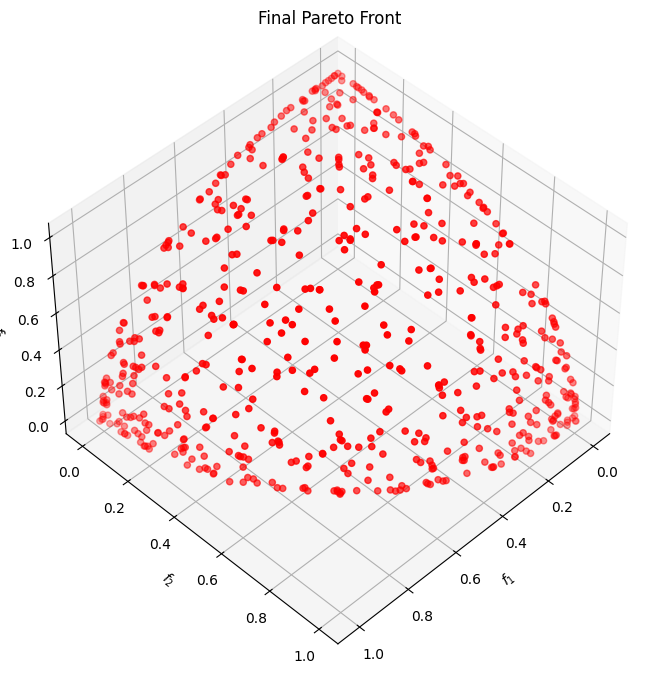

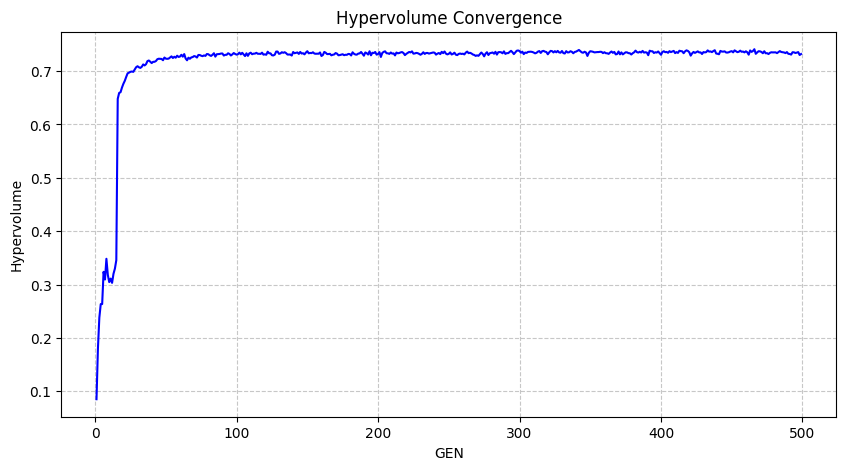

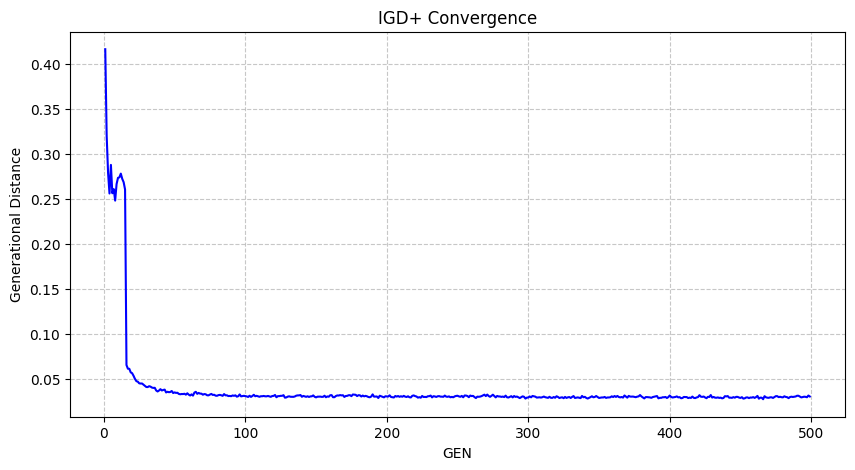

In [6]:
import matplotlib.pyplot as plt

# 3D Graphic of final pareto front
f1 = [ind.fitness.values[0] for ind in pop]
f2 = [ind.fitness.values[1] for ind in pop]
f3 = [ind.fitness.values[2] for ind in pop]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(f1, f2, f3, c='r', marker='o', label='Solutions')
ax.set_title('Final Pareto Front')
ax.set_xlabel('$f_1$')
ax.set_ylabel('$f_2$')
ax.set_zlabel('$f_3$')
ax.view_init(elev=45, azim=45)
plt.show()

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()